# Assignment 1 - Airbnb Price Prediction pipeline

## Student Details:-
- Name: Praveen Kumar Saravanan
- Student Number: S4163448
- Course Code: COSC2793

I built and evaluated a supervised machine learning pipeline to predict Airbnb nightly price using listing, host, and location features. This notebook uses a fixed seed of 42 (`RANDOM_STATE = 42`) to ensure reproducible results.

`sns.set_theme(style='whitegrid')` is used for consistent chart styling and readable plots.

## How to run this notebook
1. Keep `train_data.csv` and `test_data.csv` in the same folder as this notebook.
2. Run all cells from top to bottom.
3. The predictions file is saved as `s4163448_predictions.csv` based on the value set in the imports cell.
4. Required packages: numpy, pandas, seaborn, matplotlib, scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
student_number = 's4163448'
sns.set_theme(style='whitegrid')

## Task Definition and Evaluation Framework

- **Task type**: Supervised regression.
- **Target variable**: `price` (nightly listing price).
- **Why regression**: `price` is continuous and should be estimated from available features.


### Evaluation Design
- Hold-out split: 80% training, 20% validation.
- Stability estimate: 5-fold cross-validation on training split.
- Metrics:
  - MAE: average absolute error in price units (easy business interpretation).
  - RMSE: penalizes large errors more strongly than MAE.
  - R2: proportion of variance explained by the model.


## Dataset overview
- Train data contains the target column `price`; test data does not.
- Features include host status, location, room type, capacity, rooms, review metrics, and host listings count.
- Data types and descriptive statistics are shown in the tables below.
- Missing values are checked and summarized in the next section.

In [2]:
train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
display(train_df.head())
display(train_df.dtypes.to_frame('dtype'))

Train shape: (8586, 16)
Test shape: (8585, 15)


,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
0,f,Kingston,Australia,-38.022565,145.098937,Entire home/apt,5,1.0,2.0,4.0,111,3,28,94.0,t,1
1,f,Yarra,Australia,-37.782125,144.988079,Entire home/apt,3,1.0,1.0,1.0,80,1,59,93.0,t,1
2,t,Port Phillip,Australia,-37.853710,144.981529,Entire home/apt,4,1.0,1.0,2.0,150,2,14,100.0,f,1
3,f,Glen Eira,Australia,-37.876393,145.036635,Entire home/apt,2,1.0,1.0,1.0,125,1,39,97.0,f,55
4,f,Melbourne,Australia,-37.810398,144.950113,Entire home/apt,3,1.0,1.0,2.0,79,3,7,97.0,t,1


,dtype
host_is_superhost,str
city,str
country,str
latitude,float64
longitude,float64
room_type,str
accommodates,int64
bathrooms,float64
bedrooms,float64
beds,float64


In [3]:
display(train_df.describe(include='all').T)
print('Missing values (train):')
display(train_df.isna().sum()[train_df.isna().sum() > 0])

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
host_is_superhost,8586,2,f,6105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,8586,30,Melbourne,2917,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8586,1,Australia,8586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,8586.0,NaN,NaN,NaN,-37.825074,0.065145,-38.224427,-37.849202,-37.81646,-37.802849,-37.491059
longitude,8586.0,NaN,NaN,NaN,145.009374,0.130473,144.531993,144.957065,144.977004,145.008316,145.76025
room_type,8586,3,Entire home/apt,5771,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,8586.0,NaN,NaN,NaN,3.559865,2.225801,1.0,2.0,3.0,4.0,16.0
bathrooms,8586.0,NaN,NaN,NaN,1.28232,0.557906,0.0,1.0,1.0,1.5,9.0
bedrooms,8586.0,NaN,NaN,NaN,1.533077,0.916369,0.0,1.0,1.0,2.0,10.0
beds,8586.0,NaN,NaN,NaN,2.036222,1.544967,0.0,1.0,2.0,2.0,18.0


Missing values (train):


Series([], dtype: int64)

### Per-feature statistics and categorical distributions
Numeric summary includes all numeric columns (including `price`), and categorical summary lists unique values plus the most frequent category and its count.

In [4]:
# Per-feature statistics
numeric_stats = (
    train_df.select_dtypes(include=[np.number])
    .agg(['min', 'max', 'mean', 'median', 'std'])
    .T
    .round(3)
)

display(numeric_stats)

cat_cols = train_df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
if len(cat_cols) > 0:
    categorical_stats = train_df[cat_cols].describe().T[['unique', 'top', 'freq']]
    display(categorical_stats)
else:
    print('No categorical features found.')

,min,max,mean,median,std
latitude,-38.224,-37.491,-37.825,-37.816,0.065
longitude,144.532,145.760,145.009,144.977,0.130
accommodates,1.000,16.000,3.560,3.000,2.226
bathrooms,0.000,9.000,1.282,1.000,0.558
bedrooms,0.000,10.000,1.533,1.000,0.916
beds,0.000,18.000,2.036,2.000,1.545
price,0.000,3000.000,139.771,115.000,123.293
minimum_nights,1.000,1000.000,3.159,2.000,20.788
number_of_reviews,1.000,479.000,27.947,11.000,42.410
review_scores_rating,20.000,100.000,94.176,97.000,8.472


,unique,top,freq
host_is_superhost,2,f,6105
city,30,Melbourne,2917
country,1,Australia,8586
room_type,3,Entire home/apt,5771
instant_bookable,2,f,4461


In [5]:
# Missingness profile
missing_counts = train_df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

if len(missing_counts) > 0:
    plt.figure(figsize=(8, 4))
    sns.barplot(x=missing_counts.index, y=missing_counts.values, color='steelblue')
    plt.xticks(rotation=45, ha='right')
    plt.title('Missing values per feature (train)')
    plt.ylabel('Count of missing values')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values in training data.')

No missing values in training data.


## Initial Data Interpretation

The dataset contains **8,586 training rows** and **8,585 test rows**. The training data has 16 columns (15 predictors + 1 target `price`), while the test data has 15 predictor columns.

### Feature types
- Categorical: `host_is_superhost`, `city`, `country`, `room_type`, `instant_bookable`
- Numerical: `latitude`, `longitude`, `accommodates`, `bathrooms`, `bedrooms`, `beds`, `minimum_nights`, `number_of_reviews`, `review_scores_rating`, `calculated_host_listings_count`

### Missingness
No missing values were detected in the provided training set at runtime. Imputation remains in the pipeline as a robust safeguard for reproducibility and for potential future data with incomplete records.

### Validity note
Even with complete data, learned relationships remain correlational. Pricing can also be influenced by unobserved factors (seasonality, event periods, listing quality details), which limits causal interpretation.

In [6]:
X = train_df.drop(columns=['price'])
y = train_df['price']

categorical_features = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
numeric_features = [c for c in X.columns if c not in categorical_features]

print('Categorical:', categorical_features)
print('Numeric:', numeric_features)


Categorical: ['host_is_superhost', 'city', 'country', 'room_type', 'instant_bookable']
Numeric: ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'calculated_host_listings_count']


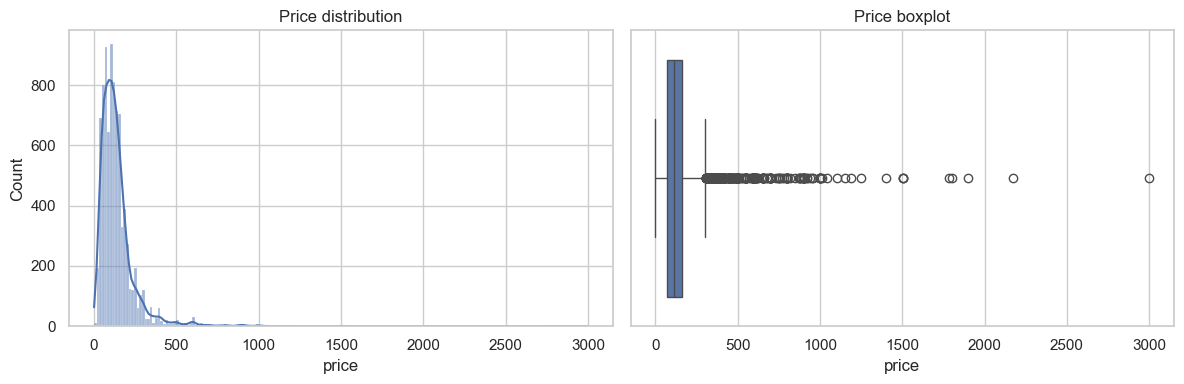

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y, kde=True, ax=axes[0])
axes[0].set_title('Price distribution')
sns.boxplot(x=y, ax=axes[1])
axes[1].set_title('Price boxplot')
plt.tight_layout()
plt.show()

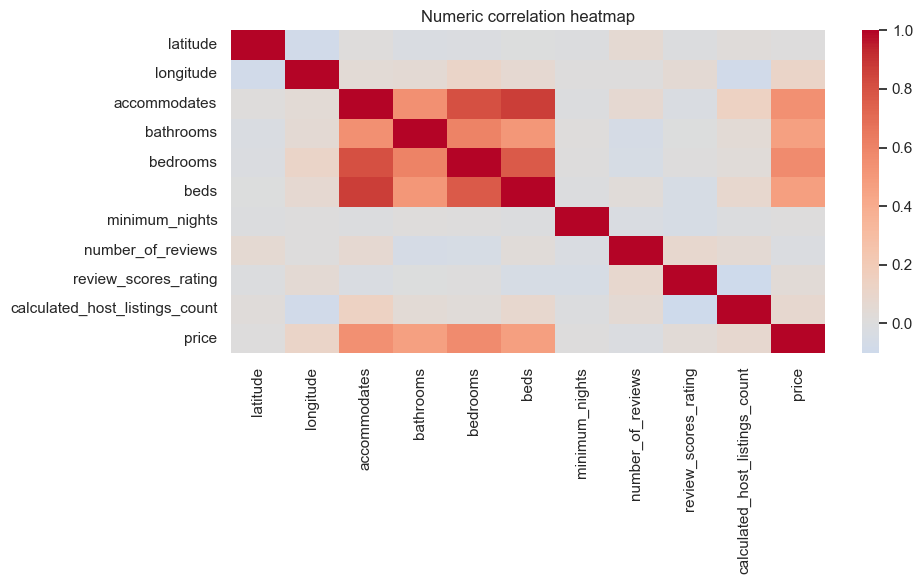

In [8]:
corr = train_df[numeric_features + ['price']].corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Numeric correlation heatmap')
plt.tight_layout()
plt.show()


## EDA Interpretation

The `price` distribution is right-skewed with visible high-price outliers, indicating that a minority of listings are substantially more expensive than typical listings. This motivates using both MAE and RMSE: MAE for average error magnitude, RMSE for sensitivity to large misses.

From the correlation heatmap, location and capacity-related variables (for example `accommodates`, `bedrooms`, and geographic coordinates) show meaningful linear relationships with `price`, though strengths vary and are not sufficient alone for perfect prediction.

All available features are retained initially to avoid premature feature dropping. Regularized models (Ridge/Lasso) then provide controlled complexity and help reduce the impact of weak or redundant predictors.

Correlation results are used for interpretation and model design only; they do not establish causation.

In [9]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
    ]
)

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

def evaluate(name, model):
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)

    val_pred = pipe.predict(X_val)
    val_m = metrics(y_val, val_pred)

    cv = cross_validate(
        pipe, X_train, y_train, cv=kfold,
        scoring=('neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2'),
        n_jobs=-1
    )

    return {
        'Model': name,
        'Val_MAE': val_m['MAE'],
        'Val_RMSE': val_m['RMSE'],
        'Val_R2': val_m['R2'],
        'CV_MAE': -cv['test_neg_mean_absolute_error'].mean(),
        'CV_RMSE': -cv['test_neg_root_mean_squared_error'].mean(),
        'CV_R2': cv['test_r2'].mean()
    }, pipe


## Pipeline Design

- `ColumnTransformer` ensures each feature type gets appropriate preprocessing.
- Median imputation is robust for skewed numerical features.
- Most-frequent categorical imputation is simple and consistent for low missingness.
- One-hot encoding makes categorical values usable by linear models.
- Standardization is important for fair regularization in Ridge/Lasso.
- Wrapping preprocessing + model in a single pipeline reduces leakage risk.

In [10]:
# Model 1: Linear Regression
linear_row, linear_pipe = evaluate('LinearRegression', LinearRegression())
display(pd.DataFrame([linear_row]))

,Model,Val_MAE,Val_RMSE,Val_R2,CV_MAE,CV_RMSE,CV_R2
0,LinearRegression,47.816145,103.683616,0.395486,47.851442,90.68427,0.43161


,Model,Val_MAE,Val_RMSE,Val_R2,CV_MAE,CV_RMSE,CV_R2,alpha
0,Ridge(alpha=31.62),47.168279,103.572006,0.396786,47.288202,90.582778,0.432870,31.622777
1,Ridge(alpha=10),47.429135,103.616289,0.396270,47.576748,90.616649,0.432465,10.000000
2,Ridge(alpha=100),46.939860,103.622347,0.396200,47.007291,90.716613,0.431169,100.000000
3,Ridge(alpha=3.162),47.615579,103.650720,0.395869,47.743404,90.655506,0.431982,3.162278
4,Ridge(alpha=1),47.729169,103.668752,0.395659,47.811098,90.671841,0.431773,1.000000


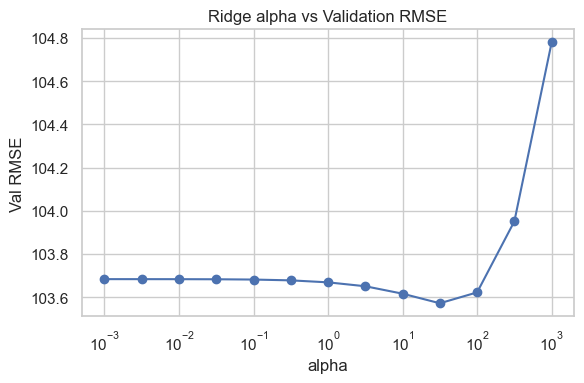

In [11]:
# Model 2: Ridge (tune alpha)
ridge_alphas = np.logspace(-3, 3, 13)
ridge_rows = []

for a in ridge_alphas:
    row, _ = evaluate(f'Ridge(alpha={a:.4g})', Ridge(alpha=float(a), random_state=RANDOM_STATE))
    row['alpha'] = a
    ridge_rows.append(row)

ridge_df = pd.DataFrame(ridge_rows).sort_values('Val_RMSE').reset_index(drop=True)
best_ridge_alpha = float(ridge_df.loc[0, 'alpha'])
display(ridge_df.head())

ridge_plot = ridge_df.sort_values('alpha')
plt.figure(figsize=(6, 4))
plt.plot(ridge_plot['alpha'], ridge_plot['Val_RMSE'], marker='o')
plt.xscale('log')
plt.title('Ridge alpha vs Validation RMSE')
plt.xlabel('alpha')
plt.ylabel('Val RMSE')
plt.tight_layout()
plt.show()


In [12]:
# Model 3: Lasso (tune alpha)
lasso_alphas = np.logspace(-4, 1, 12)
lasso_rows = []

for a in lasso_alphas:
    row, _ = evaluate(f'Lasso(alpha={a:.4g})', Lasso(alpha=float(a), random_state=RANDOM_STATE, max_iter=20000))
    row['alpha'] = a
    lasso_rows.append(row)

lasso_df = pd.DataFrame(lasso_rows).sort_values('Val_RMSE').reset_index(drop=True)
best_lasso_alpha = float(lasso_df.loc[0, 'alpha'])
display(lasso_df.head())


C:\Users\prave\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.956e+06, tolerance: 9.995e+03
  model = cd_fast.enet_coordinate_descent(


,Model,Val_MAE,Val_RMSE,Val_R2,CV_MAE,CV_RMSE,CV_R2,alpha
0,Lasso(alpha=0.152),47.006609,103.560857,0.396916,47.244716,90.597853,0.432696,0.151991
1,Lasso(alpha=0.05337),47.334302,103.590273,0.396574,47.546963,90.621019,0.432409,0.053367
2,Lasso(alpha=0.4329),46.626368,103.678475,0.395546,46.855299,90.757726,0.430722,0.432876
3,Lasso(alpha=0.006579),47.722292,103.680698,0.395520,47.810304,90.679079,0.431682,0.006579
4,Lasso(alpha=0.00231),47.780929,103.681465,0.395511,47.836815,90.681440,0.431648,0.002310


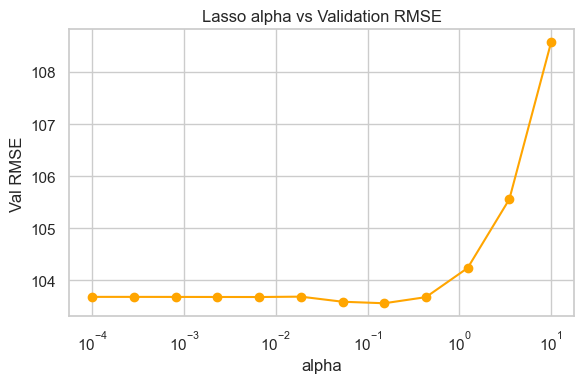

In [13]:
lasso_plot = lasso_df.sort_values('alpha')
plt.figure(figsize=(6, 4))
plt.plot(lasso_plot['alpha'], lasso_plot['Val_RMSE'], marker='o', color='orange')
plt.xscale('log')
plt.title('Lasso alpha vs Validation RMSE')
plt.xlabel('alpha')
plt.ylabel('Val RMSE')
plt.tight_layout()
plt.show()

## Hyperparameter Analysis (Ridge/Lasso Alpha)

Hyperparameter tuning shows the expected bias-variance pattern:
- Very small `alpha` behaves similarly to ordinary least squares (weak regularization).
- Very large `alpha` overshrinks coefficients and can underfit.
- Intermediate values balance generalization and stability.

Using validation RMSE for ranking and CV metrics for stability checks, the best-performing candidate in this run was **Lasso(alpha = 0.152)**.

Top validation result:
- Val_MAE = 47.0066
- Val_RMSE = 103.5609
- Val_R2 = 0.3969

Corresponding CV result:
- CV_MAE = 47.2447
- CV_RMSE = 90.5979
- CV_R2 = 0.4327

In [14]:
comparison = pd.DataFrame([
    linear_row,
    ridge_df.loc[0].to_dict(),
    lasso_df.loc[0].to_dict()
]).sort_values('Val_RMSE').reset_index(drop=True)

display(comparison[['Model', 'Val_MAE', 'Val_RMSE', 'Val_R2', 'CV_MAE', 'CV_RMSE', 'CV_R2']])
best_model_name = comparison.loc[0, 'Model']
print('Selected model:', best_model_name)

if best_model_name.startswith('LinearRegression'):
    selected_estimator = LinearRegression()
elif best_model_name.startswith('Ridge'):
    selected_estimator = Ridge(alpha=best_ridge_alpha, random_state=RANDOM_STATE)
else:
    selected_estimator = Lasso(alpha=best_lasso_alpha, random_state=RANDOM_STATE, max_iter=20000)

,Model,Val_MAE,Val_RMSE,Val_R2,CV_MAE,CV_RMSE,CV_R2
0,Lasso(alpha=0.152),47.006609,103.560857,0.396916,47.244716,90.597853,0.432696
1,Ridge(alpha=31.62),47.168279,103.572006,0.396786,47.288202,90.582778,0.432870
2,LinearRegression,47.816145,103.683616,0.395486,47.851442,90.684270,0.431610


Selected model: Lasso(alpha=0.152)


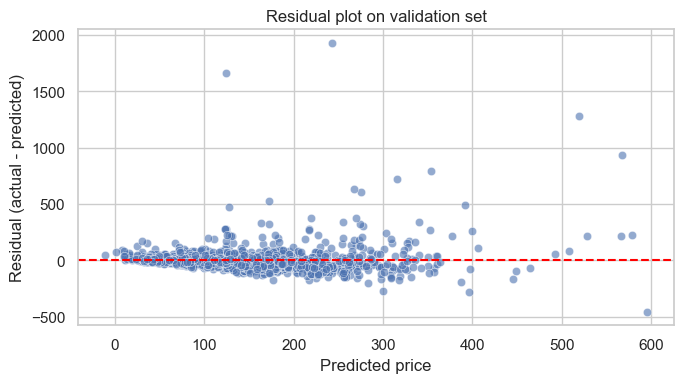

In [15]:
# Error analysis on validation set
analysis_pipe = Pipeline([('preprocess', preprocessor), ('model', selected_estimator)])
analysis_pipe.fit(X_train, y_train)
val_pred = analysis_pipe.predict(X_val)
residuals = y_val - val_pred

plt.figure(figsize=(7, 4))
sns.scatterplot(x=val_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted price')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual plot on validation set')
plt.tight_layout()
plt.show()

In [16]:
# Feature importance via coefficients (for linear family)
importance_pipe = Pipeline([('preprocess', preprocessor), ('model', selected_estimator)])
importance_pipe.fit(X, y)
model = importance_pipe.named_steps['model']
feature_names = importance_pipe.named_steps['preprocess'].get_feature_names_out()
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': model.coef_})
coef_df = coef_df.sort_values('coefficient')
print('Most negative coefficients:')
display(coef_df.head(10))
print('Most positive coefficients:')
display(coef_df.tail(10))

Most negative coefficients:


,feature,coefficient
39,cat__city_Wyndham,-18.638058
37,cat__city_Whitehorse,-16.670157
45,cat__room_type_Shared room,-10.647926
31,cat__city_Monash,-8.074481
18,cat__city_Darebin,-6.611860
7,num__number_of_reviews,-6.371734
5,num__beds,-3.179536
20,cat__city_Glen Eira,-2.510346
10,cat__host_is_superhost_f,-1.731969
0,num__latitude,-0.501442


Most positive coefficients:


,feature,coefficient
2,num__accommodates,17.349913
13,cat__city_Bayside,22.700860
35,cat__city_Port Phillip,25.418045
3,num__bathrooms,25.667463
40,cat__city_Yarra,26.138856
36,cat__city_Stonnington,27.142381
4,num__bedrooms,33.277055
29,cat__city_Melbourne,33.595685
43,cat__room_type_Entire home/apt,46.857801
41,cat__city_Yarra Ranges,69.044806


In [17]:
# Train final model on full training data and predict test set
final_pipeline = Pipeline([('preprocess', preprocessor), ('model', selected_estimator)])
final_pipeline.fit(X, y)
test_pred = np.clip(final_pipeline.predict(test_df), a_min=0, a_max=None)

In [18]:
out_file = f'{student_number}_predictions.csv'
pd.DataFrame({'price': test_pred}).to_csv(out_file, index=False)
print('Saved prediction file:', out_file)
pred_df = pd.DataFrame({'price': test_pred})
display(pred_df.head())
print('Prediction shape:', pred_df.shape)
assert pred_df.shape[0] == test_df.shape[0]
assert list(pred_df.columns) == ['price']

Saved prediction file: s4163448_predictions.csv


,price
0,25.685031
1,128.311573
2,63.767173
3,19.931735
4,83.488276


Prediction shape: (8585, 1)


## Final Analysis

### Model adequacy for practice
The selected model is suitable as a **decision-support tool** for initial price recommendations, not as a fully autonomous pricing decision system. Error magnitudes indicate useful directional guidance, but not perfect precision for all listings.

### Error behavior and limitations
- Residual analysis should be checked for systematic over/underestimation across price ranges.
- Linear-family models may miss nonlinear interactions in real markets.
- The dataset is a processed subset and may not represent all Melbourne market conditions or time periods.
- Omitted variables (seasonality, event demand, listing quality details) can reduce predictive performance.

### Feature importance (COSC2793 focus)
Coefficient-based interpretation from the selected linear model provides directional insights into which transformed features increase or decrease predicted price. Interpretation must be cautious because coefficients are affected by scaling and one-hot encoding reference levels.

### Ethical and professional responsibilities
- Historical data may contain socioeconomic or geographic bias; model outputs can propagate this bias.
- Users should be informed about uncertainty and expected error.
- Final accountability for pricing decisions remains with the human decision-maker.
- Data must be handled responsibly and only for the assignment's permitted scope.

### Conclusion
Lasso(alpha = 0.152) was selected due to best validation RMSE among evaluated linear-family models with competitive cross-validation performance. The model is practically useful for baseline recommendations, with clear limitations and ethical constraints that should be acknowledged in deployment contexts.

## GenAI usage statement
I used GenAI tools to help with debugging and markdown wording. Prompts used are listed in the report appendix per course policy.
